<a href="https://colab.research.google.com/github/Th1ago01/MVP---MACHINE-LEARNING---CONSUMO-ELETRICO/blob/main/MVP_consumo_energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Thiago Fragoso Gomes da Silva

**Matrícula:**  4052026000798

**Data:** 08/06/2026

**Dataset:** Consumo horário de energia elétrica — Fábrica de Água (fonte própria, exportação do sistema da CCEE e disponibilizado no [github](https://github.com/Th1ago01/MVP_MACHINE_LEARNING/blob/main/consumo_fabrica_privado.csv) com exclusão de algumas informações sensíveis.)

**Tipo de problema:** Regressão e Séries Temporais

---


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | X |
| Dataset descrito, com fonte, atributos e restrições | X |
| Dataset carregado por URL pública ou fonte diretamente acessível | X |
| Análise exploratória objetiva, conectada à modelagem | X |
| Divisão adequada em treino/teste e, se aplicável, validação | X |
| Prevenção de vazamento de dados | X |
| Tratamentos de dados justificados | X |
| Pipeline ou sequência reprodutível de pré-processamento | X |
| Modelo baseline definido | X |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | X |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | X |
| Avaliação com métricas coerentes com o problema | X |
| Discussão de overfitting/underfitting, limitações e melhorias | X |
| Código limpo, organizado e executável do início ao fim | X |
| Conclusão conectada ao objetivo inicial | X |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

Está sendo analisada uma fábrica de água mineral que opera bombas, compressores e linhas de envase com consumo energético relevante e variável ao longo do dia. O custo com energia elétrica representa uma parcela expressiva do custo operacional.

Atualmente, o planejamento operacional não utiliza previsões de consumo energético — as decisões de ligamento de equipamentos são tomadas de forma reativa. Isso gera dois problemas:

1. **Custos desnecessários** em horários de ponta, quando a tarifa é mais alta.
2. **Dificuldade de identificar anomalias** de consumo que indicam falhas em equipamentos.

**Decisão que o modelo deve apoiar:** antecipar o consumo horário de energia nas próximas horas, permitindo ao gestor industrial planejar a operação dos equipamentos com base na previsão.

**OBS:** por questões de sensibilidade dos dados, o nome real da fábrica não será citado diretamente.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para **prever o consumo horário de energia elétrica (kWh)** da fábrica de água a partir de features de calendário e valores históricos de consumo, comparando um baseline ingênuo com modelos candidatos supervisionados e um modelo estatístico de séries temporais, e discutindo as limitações da solução.



## 1.3 Tipo de problema

**Tipo escolhido:** **Séries temporais — Forecasting (Regressão Temporal)**

**Justificativa:** O consumo de energia é uma série temporal horária com padrões de sazonalidade bem definidos. O problema é tratado como **regressão supervisionada** após a transformação da série em um dataset tabular por meio de features de lag (valores passados) e features de calendário (hora, dia da semana, mês, estações do ano).



## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. O consumo apresenta padrões regulares de sazonalidade diária (turnos de produção) e semanal (fins de semana vs. dias úteis).
2. Os valores de consumo das horas anteriores (lags) são preditores relevantes do consumo futuro.
3. Modelos não-lineares (RF, GBM) desempenharão melhor.

**Premissas:**
- O processo produtivo não sofreu mudanças estruturais relevantes no período coberto.
- A divisão treino/teste respeita a ordem cronológica — sem embaralhamento.
- Transformações são ajustadas somente nos dados de treino para evitar vazamento de dados.

**Critérios de sucesso:**
- Métrica principal: **RMSE**
- Critério mínimo: superar o baseline ingênuo em pelo menos 20% no RMSE
- Métrica secundária: **MAPE** (interpretável em termos percentuais para o gestor)

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

In [ ]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 100

SEED = 160200
np.random.seed(SEED)
random.seed(SEED)




## 2.1 Dependências adicionais

As bibliotecas **statsmodels** e **seaborn** já vêm pré-instaladas no Google Colab. Nenhuma instalação adicional é necessária para executar este notebook.


In [ ]:
# Exemplo: descomente apenas se necessário.
# !pip install -q imbalanced-learn xgboost lightgbm catboost optuna # modelos extras
# !pip install -q seaborn plotly # visualização
# !pip install -q statsmodels pmdarima # cálculo de estatísticas (extras)


## 2.2 Funções auxiliares

Funções reutilizáveis definidas aqui evitam repetição de código nas seções de avaliação.

In [ ]:
def evaluate_regression(y_true, y_pred):
    """Métricas de regressão para séries temporais.
    O MAPE é calculado ignorando horas com consumo zero (paradas) para evitar
    divisão por zero. Ainda assim ele é inflado pelas horas de consumo muito
    baixo (madrugada/fim de semana), então reportamos também o WAPE, que é
    estável na presença de valores próximos de zero e interpretável como
    'erro total em % do consumo total'.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_true, y_pred)

    mask = y_true != 0  # evita divisão por zero (há 110 zeros no histórico)
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

    return {
        "MAE":  round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE": round(np.sqrt(mse), 2),
        "MAPE": round(mape, 2),
        "WAPE": round(wape, 2),
        "R2":   round(r2_score(y_true, y_pred), 4),
    }


def show_results_table(results_dict):
    #Exibe resultados como DataFrame ordenado por RMSE.
    return pd.DataFrame(results_dict).T.sort_values("RMSE")


def plot_forecast(ts, y_true, y_pred, titulo, n_vis=24*14, label_pred="Modelo"):
    #Plota previsão vs real nas últimas n_vis observações do período de teste.
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(ts[-n_vis:], y_true[-n_vis:], label="Real", color="steelblue", lw=1.5)
    ax.plot(ts[-n_vis:], y_pred[-n_vis:], label=label_pred, color="coral", lw=1.2, alpha=0.9)
    ax.set_title(titulo)
    ax.set_ylabel("Consumo (kWh)")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
    plt.tight_layout()
    plt.show()


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

| Atributo | Descrição |
|---|---|
| **Nome** | Consumo Horário de Energia|
| **Fonte** | Exportação do sistema da CCEE, disponível apenas para a empresa ou seus representantes no ambiente do Mercado Livre de Energia |
| **Período** | 2024 e 2025 |
| **Granularidade** | Horária (horas 1 a 24 por dia) |
| **Por que este dataset** | Dado real de uma operação industrial, com padrões sazonais claros e relevância prática para otimização de custos energéticos |
| **Restrições** | O arquivo foi pré-tratado de forma a retirar qualquer tipo de informação sensível sobre a empresa no Dataset |
| **Licença** | Uso acadêmico interno pelo local onde trabalho |


## 3.2 Carga dos dados

Substitua o exemplo abaixo pelo carregamento real do seu dataset.

> **Comentário:** caso use Kaggle ou outra fonte que exija autenticação, prefira disponibilizar uma versão pública alternativa ou explicar claramente como o professor conseguirá executar o notebook sem configuração adicional.


In [ ]:
URL = "https://raw.githubusercontent.com/Th1ago01/MVP---MACHINE-LEARNING---CONSUMO-ELETRICO/refs/heads/main/consumo_fabrica_privado.csv"
df_raw = pd.read_csv(URL)

df_raw.head()


,Ponto / Grupo,Data,Hora,Ativa C (kWh),Qualidade,Origem
0,RJAQTEENTR101 (L),01/04/2024,1,"20,144",Completo,COLETA DIÁRIA
1,RJAQTEENTR101 (L),01/04/2024,2,"19,769",Completo,COLETA DIÁRIA
2,RJAQTEENTR101 (L),01/04/2024,3,"19,584",Completo,COLETA DIÁRIA
3,RJAQTEENTR101 (L),01/04/2024,4,"19,742",Completo,COLETA DIÁRIA
4,RJAQTEENTR101 (L),01/04/2024,5,"20,481",Completo,COLETA DIÁRIA


## 3.3 Visão geral do dataset



In [ ]:
print("Formato do dataset:", df_raw.shape)
print("\nTipos de dados:")
display(df_raw.dtypes.to_frame("tipo"))

Formato do dataset: (17544, 6)

Tipos de dados:


,tipo
Ponto / Grupo,object
Data,object
Hora,int64
Ativa C (kWh),object
Qualidade,object
Origem,object


In [ ]:
print("\nValores ausentes por coluna:")
display(df_raw.isna().sum().to_frame("ausentes"))



Valores ausentes por coluna:


,ausentes
Ponto / Grupo,0
Data,0
Hora,0
Ativa C (kWh),0
Qualidade,0
Origem,0


In [ ]:
print("\nDuplicatas:", df_raw.duplicated().sum())



Duplicatas: 0


In [ ]:
display(df_raw.sample(5, random_state=SEED))


,Ponto / Grupo,Data,Hora,Ativa C (kWh),Qualidade,Origem
14777,RJAQTEENTR101 (L),08/08/2025,18,"31,850",Completo,COLETA DIÁRIA
8203,RJAQTEENTR101 (L),06/09/2024,20,"30,071",Completo,COLETA DIÁRIA
10264,RJAQTEENTR101 (L),04/12/2025,17,"1.150,787",Completo,COLETA DIÁRIA
14506,RJAQTEENTR101 (L),28/07/2025,11,"909,676",Completo,COLETA DIÁRIA
10990,RJAQTEENTR101 (L),03/03/2025,23,"33,794",Completo,COLETA DIÁRIA


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Ponto / Grupo | categórica | Identificador do ponto de medição | não | Valor único em todo o dataset |
| Data | data | Data da leitura (dd/mm/aaaa) | sim (derivada) | Usada para gerar features de calendário |
| Hora | numérica | Hora da leitura (1 a 24) | sim (derivada) | Convertida para 0–23 e features cíclicas |
| Ativa C (kWh) | numérica (string) | Consumo ativo no período — **variável-alvo** | sim | convertida para float |
| Qualidade | categórica | Qualidade da leitura | não | Valor único: Completo |
| Origem | categórica | Origem da coleta | não | Valor único: COLETA DIÁRIA |


# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


In [ ]:
# variáveis ajustadas conforme o problema
TARGET = "consumo_kwh"
PROBLEM_TYPE = "serie_temporal"

# limpeza e conversão dos tipos das colunas
df = df_raw.copy()

# converter o consumo para float
df["consumo_kwh"] = (
    df["Ativa C (kWh)"]
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Converte data e cria timestamp horário (hora 1→0, 24→23)
df["Data"] = pd.to_datetime(df["Data"], format="%d/%m/%Y")
df["hora"] = df["Hora"] - 1
df["timestamp"] = df["Data"] + pd.to_timedelta(df["hora"], unit="h")
df = df.sort_values("timestamp").reset_index(drop=True)

print("Período:", df["timestamp"].min(),df["timestamp"].max())
print("Total de registros:", len(df))
print("Distribuição do target (consumo_kwh):")
display(df["consumo_kwh"].describe().round(2).to_frame())
print(df.head(5))


Período: 2024-01-01 00:00:00 2025-12-31 23:00:00
Total de registros: 17544
Distribuição do target (consumo_kwh):


,consumo_kwh
count,17544.00
mean,348.48
std,428.22
min,0.00
25%,18.86
50%,32.01
75%,781.93
max,1299.60


       Ponto / Grupo       Data  Hora Ativa C (kWh) Qualidade         Origem  \
0  RJAQTEENTR101 (L) 2024-01-01     1        22,617  Completo  COLETA DIÁRIA   
1  RJAQTEENTR101 (L) 2024-01-01     2        22,209  Completo  COLETA DIÁRIA   
2  RJAQTEENTR101 (L) 2024-01-01     3        20,508  Completo  COLETA DIÁRIA   
3  RJAQTEENTR101 (L) 2024-01-01     4        20,108  Completo  COLETA DIÁRIA   
4  RJAQTEENTR101 (L) 2024-01-01     5        19,440  Completo  COLETA DIÁRIA   

   consumo_kwh  hora           timestamp  
0       22.617     0 2024-01-01 00:00:00  
1       22.209     1 2024-01-01 01:00:00  
2       20.508     2 2024-01-01 02:00:00  
3       20.108     3 2024-01-01 03:00:00  
4       19.440     4 2024-01-01 04:00:00  


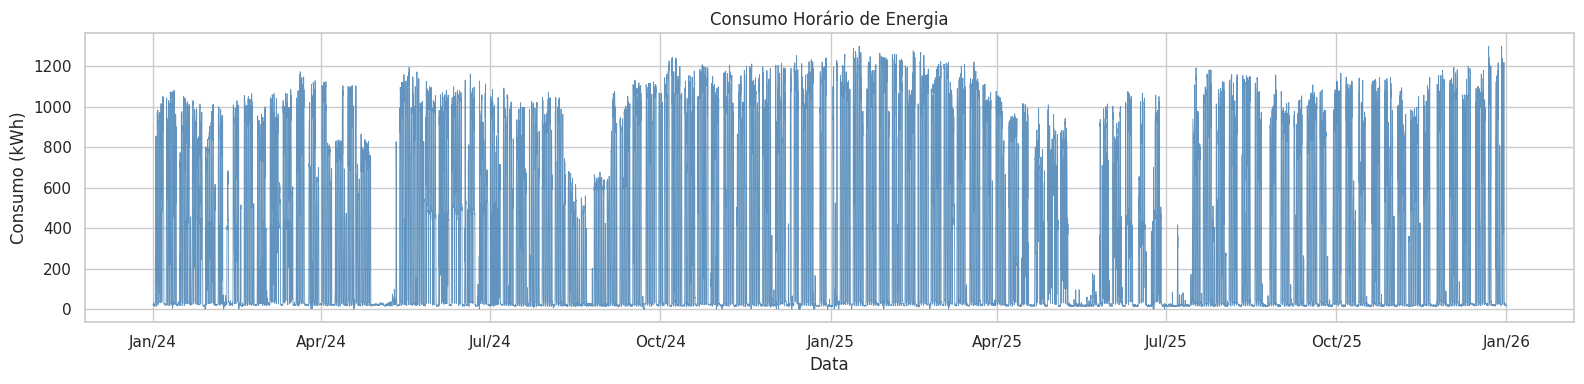

In [ ]:
# gráfico de todo o período analisado
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df["timestamp"], df["consumo_kwh"], lw=0.6, color="steelblue", alpha=0.85)
ax.set_title("Consumo Horário de Energia")
ax.set_xlabel("Data")
ax.set_ylabel("Consumo (kWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
plt.tight_layout()
plt.show()


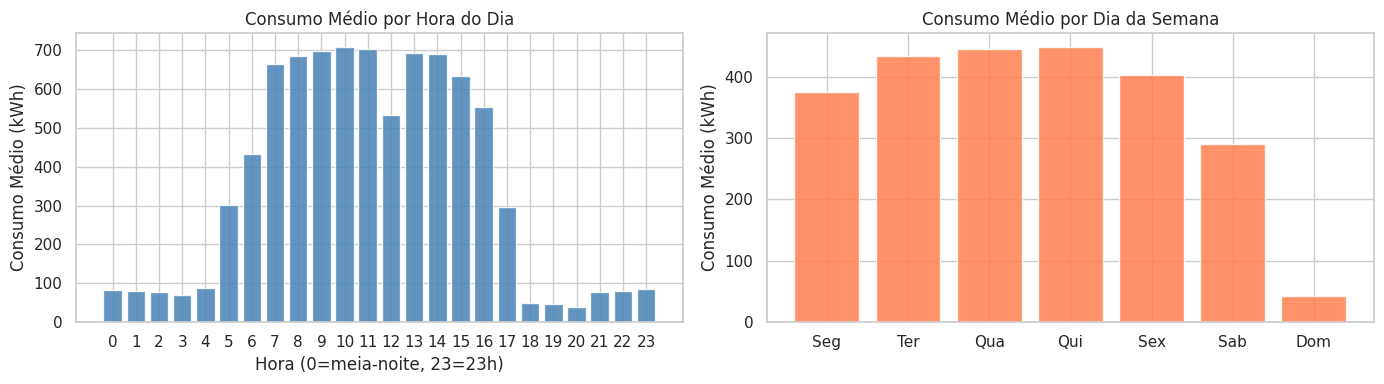

Hora de pico: 10h (709 kWh) | Hora de vale: 20h (38 kWh)


In [ ]:
#padrão diário e semanal
df["dia_semana"] = df["timestamp"].dt.dayofweek
dias_nomes = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sab", "Dom"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#perfil pra cada hora do dia
perfil_hora = df.groupby("hora")["consumo_kwh"].mean()
axes[0].bar(perfil_hora.index, perfil_hora.values, color="steelblue", alpha=0.85)
axes[0].set_title("Consumo Médio por Hora do Dia")
axes[0].set_xlabel("Hora (0=meia-noite, 23=23h)")
axes[0].set_ylabel("Consumo Médio (kWh)")
axes[0].set_xticks(range(0, 24))

#perfil de acordo com o dia da semana
perfil_dia = df.groupby("dia_semana")["consumo_kwh"].mean()
axes[1].bar(perfil_dia.index, perfil_dia.values, color="coral", alpha=0.85)
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dias_nomes)
axes[1].set_title("Consumo Médio por Dia da Semana")
axes[1].set_ylabel("Consumo Médio (kWh)")

plt.tight_layout()
plt.show()

print(f"Hora de pico: {perfil_hora.idxmax()}h ({perfil_hora.max():.0f} kWh) | "
      f"Hora de vale: {perfil_hora.idxmin()}h ({perfil_hora.min():.0f} kWh)")


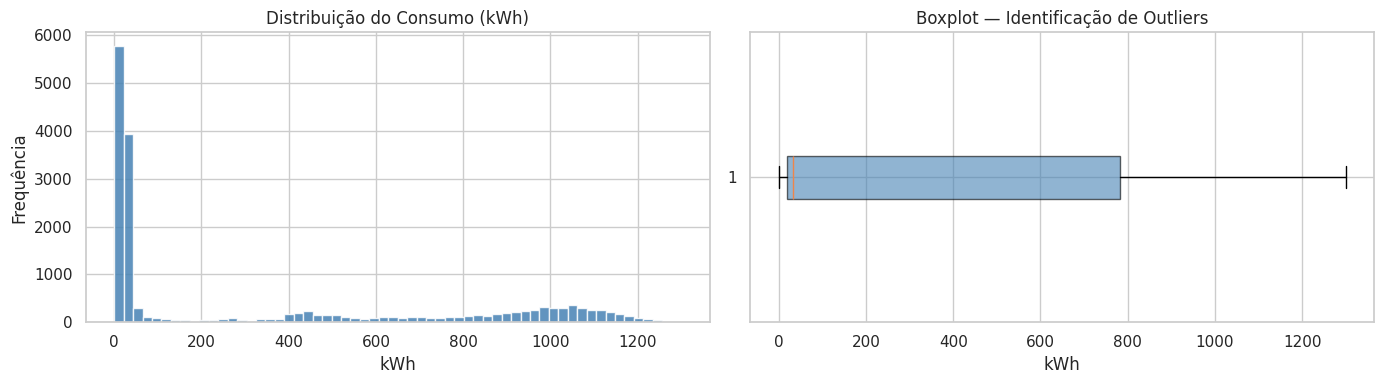

Outliers detectados (IQR): 0 (0.0% dos registros)


In [ ]:
# vendo a distribuição e outliers do consumo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["consumo_kwh"], bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribuição do Consumo (kWh)")
axes[0].set_xlabel("kWh")
axes[0].set_ylabel("Frequência")

axes[1].boxplot(df["consumo_kwh"], vert=False, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_title("Boxplot — Identificação de Outliers")
axes[1].set_xlabel("kWh")

plt.tight_layout()
plt.show()

q1, q3 = df["consumo_kwh"].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = df[(df["consumo_kwh"] < q1 - 1.5*iqr) | (df["consumo_kwh"] > q3 + 1.5*iqr)]
print(f"Outliers detectados (IQR): {len(outliers)} ({100*len(outliers)/len(df):.1f}% dos registros)")


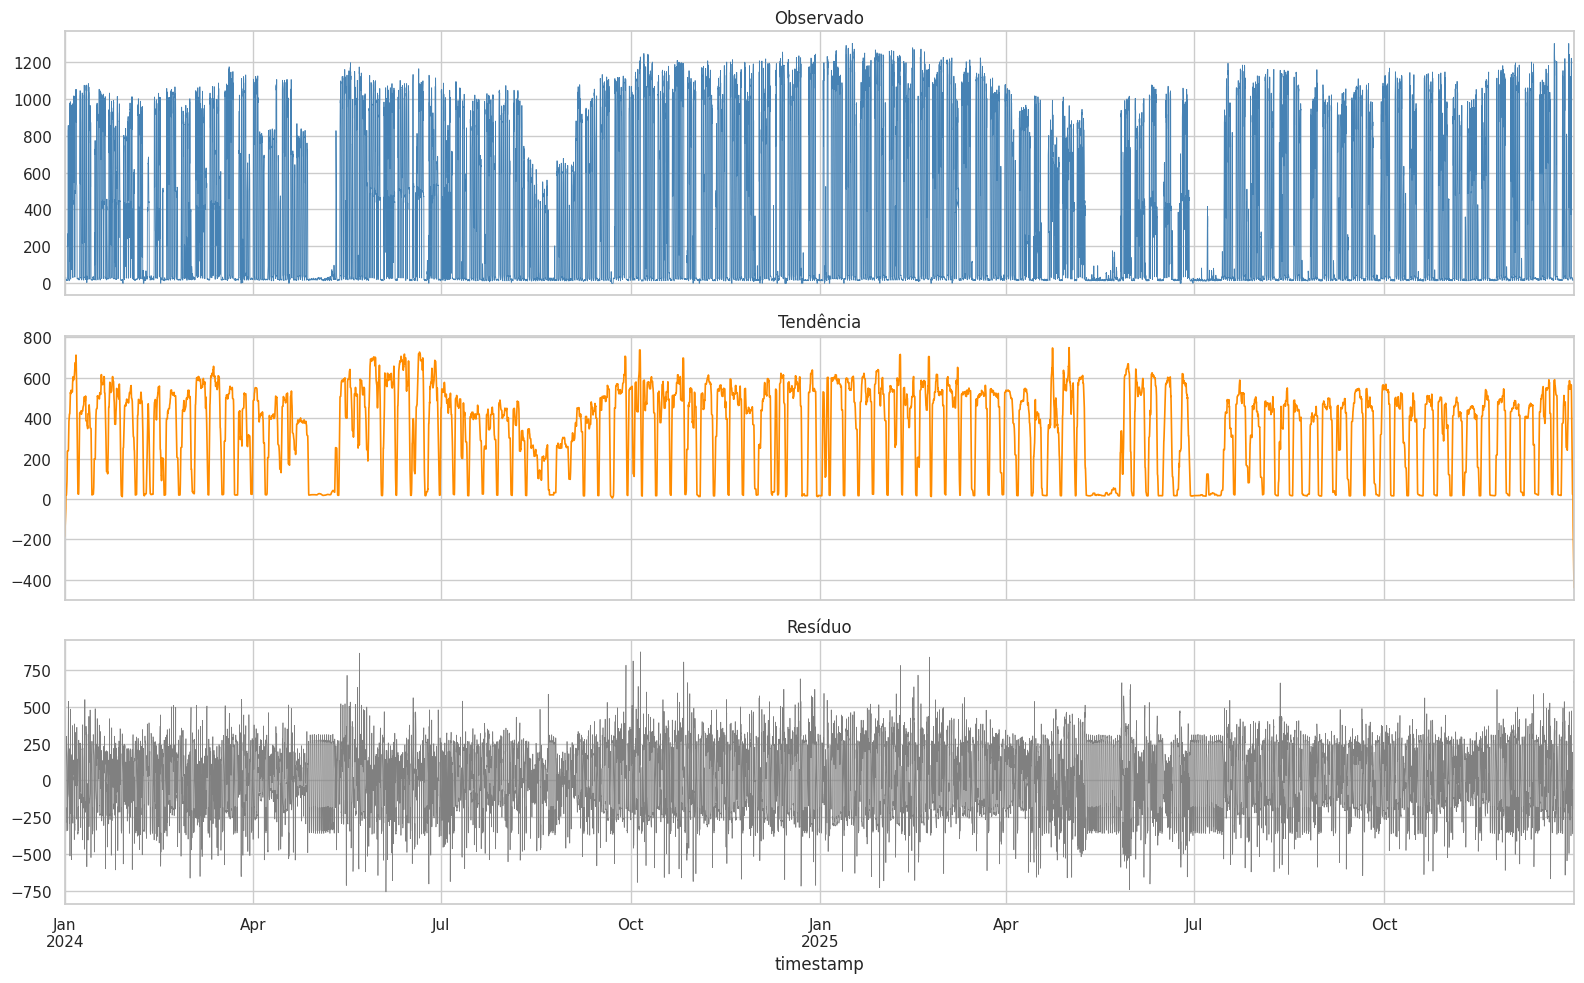

In [ ]:
# Decomposição da série (sazonalidade diária)
serie = df.set_index("timestamp")["consumo_kwh"]
decomp = seasonal_decompose(serie, model="additive", period=24, extrapolate_trend="freq")

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
decomp.observed.plot(ax=axes[0], title="Observado", color="steelblue", lw=0.6)
decomp.trend.plot(ax=axes[1], title="Tendência", color="darkorange", lw=1.2)
decomp.resid.plot(ax=axes[2], title="Resíduo", color="gray", lw=0.5)
plt.tight_layout()
plt.show()


## 4.1 Síntese da análise exploratória


**Síntese:**  
- **Sazonalidade diária clara:** o consumo é baixo nas madrugadas e fora do expediente (vale às 20h, ~38 kWh) e sobe acentuadamente durante o horário de produção, atingindo o pico às 10h (~709 kWh). A diferença entre vale e pico é de quase 20×, o que evidencia o forte controle dos turnos de produção sobre o consumo.
- **Sazonalidade semanal:** fins de semana apresentam consumo significativamente menor que os dias úteis, indicando redução aos sábados e possíveis paradas totais aos domingos.
- **Distribuição bimodal:** o histograma mostra dois regimes bem separados — horas de parada (~20 kWh) e horas de produção (centenas de kWh) — em vez de uma distribuição unimodal. Isso explica por que o critério IQR não detectou outliers (0 registros): com a distribuição tão espalhada, o intervalo interquartílico fica largo e os picos de produção, que são reais, não são sinalizados como anomalias.
- **Sem valores ausentes nem duplicatas** — o dataset está completo para todo o período (jan/2024 a dez/2025).
- **Tendência levemente ascendente** visível na decomposição, possivelmente associada a aumento de produção. Uma hipótese plausível, não testada neste MVP, é maior demanda no período chuvoso.
- **Principais preditores esperados:** hora do dia, dia da semana e lags de 1h, 24h e 168h (semana anterior).


# 5. Preparação dos dados e divisão treino/teste

A série temporal é convertida em um problema supervisionado tabular por meio de **engenharia de features**. Esta etapa é o núcleo da preparação para os modelos baseados em árvore e que imagino que performarão melhor neste problema.

**Estratégia:**
- Features de calendário capturam sazonalidades diária, semanal e mensal
- Features cíclicas (seno/cosseno) evitam a descontinuidade
- Lags de 1h a 168h (1 semana) fornecem contexto temporal recente
- Médias móveis suavizam ruído e capturam tendência local



In [ ]:
TARGET = "consumo_kwh"
PROBLEM_TYPE = "serie_temporal"
DATE_COLUMN = "timestamp"
ID_COLUMNS = []
DROP_COLUMNS = [
    "Ponto / Grupo",
    "Origem",
    "Qualidade",
    "Ativa C (kWh)",  # coluna original antes da conversão — substituída por consumo_kwh
    "Data",           # substituída pelo timestamp
    "Hora",           # substituída pela feature hora (0-23) e encodings cíclicos
    "dia_semana",     # recriada como feature cíclica
]

print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Colunas removidas:", DROP_COLUMNS)

Tipo de problema: serie_temporal
Target: consumo_kwh
Colunas removidas: ['Ponto / Grupo', 'Origem', 'Qualidade', 'Ativa C (kWh)', 'Data', 'Hora', 'dia_semana']


Treino: (14035, 10) | 2024-01-01 00:00:00 2025-08-07 18:00:00
Teste:  (3509, 10) | 2025-08-07 19:00:00 2025-12-31 23:00:00


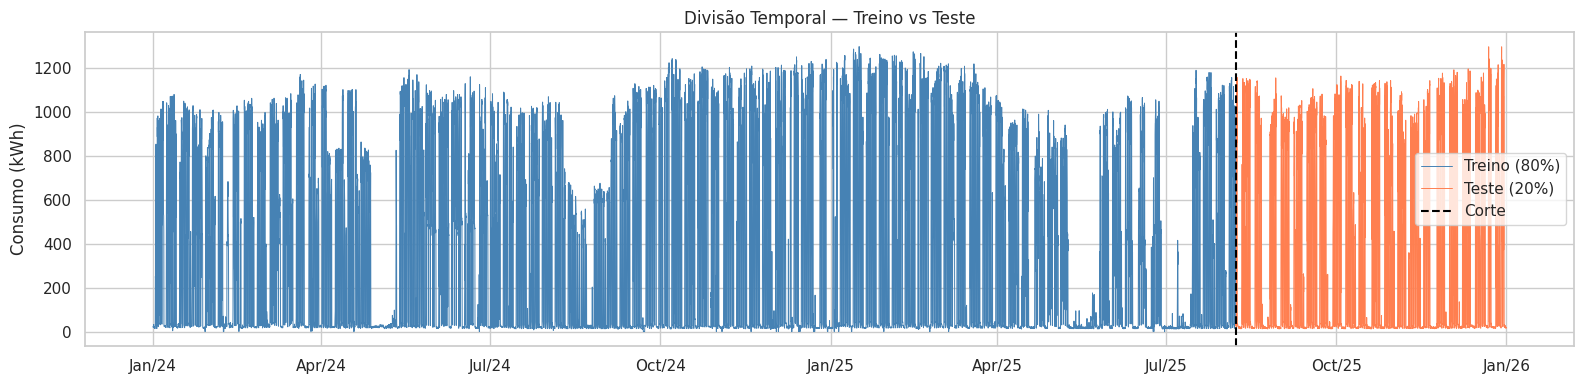

In [ ]:
#Divisão dos dados

#séries temporais: divisão cronológica, sem embaralhamento
assert DATE_COLUMN in df.columns, "DATE_COLUMN não encontrado no DataFrame."

df_sorted = df.sort_values(DATE_COLUMN).copy()
corte = int(len(df_sorted) * 0.80)

train_df = df_sorted.iloc[:corte].copy()
test_df  = df_sorted.iloc[corte:].copy()

print("Treino:", train_df.shape,
      "|", train_df[DATE_COLUMN].min(), train_df[DATE_COLUMN].max())
print("Teste: ", test_df.shape,
      "|", test_df[DATE_COLUMN].min(), test_df[DATE_COLUMN].max())

#gráfico para visualizar o corte de treino/teste
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(train_df[DATE_COLUMN], train_df[TARGET], color="steelblue", lw=0.7, label="Treino (80%)")
ax.plot(test_df[DATE_COLUMN],  test_df[TARGET],  color="coral",     lw=0.7, label="Teste (20%)")
ax.axvline(train_df[DATE_COLUMN].max(), color="black", ls="--", lw=1.5, label="Corte")
ax.set_title("Divisão Temporal — Treino vs Teste")
ax.set_ylabel("Consumo (kWh)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
plt.tight_layout()
plt.show()


## 5.1 Justificativa da divisão

Explique por que a divisão escolhida é adequada.

**Resposta:**  
Para séries temporais, a divisão deve **respeitar obrigatoriamente a ordem cronológica**. Embaralhar os dados causaria vazamento de dados futuros para o treino (data leakage), inflando artificialmente as métricas e tornando o modelo inútil na prática.

- Holdout temporal 80/20 foi preferido à validação cruzada simples pela simplicidade e clareza de interpretação.
- Para a otimização de hiperparâmetros, usamos TimeSeriesSplit, que preserva a ordem temporal em cada fold.
- Transformações como winsorizing e engenharia de features que dependem de estatísticas históricas (médias móveis, lags) são calculadas **a partir do conjunto de treino** e aplicadas ao teste sem recalcular.


# 6. Pré-processamento e pipeline

## Etapas realizadas:
1. **Winsorizing** — limita outliers extremos aos percentis 0,5% e 99,5%, preservando a escala real
2. **Engenharia de features** — cria 20+ features a partir do timestamp e do histórico de consumo
3. **Pipeline scikit-learn** — encapsula imputação e scaling de forma reproduzível


In [ ]:
#Winsorizing do target (limites do treino, aplicado à série completa)
# Os limites são calculados SOMENTE com o período de treino (train_df), para não
# vazar informação do teste. O clip é aplicado a df_sorted ANTES da engenharia de
# features — assim o target, os lags e as médias móveis usam valores winsorizados.

p005 = train_df[TARGET].quantile(0.005)
p995 = train_df[TARGET].quantile(0.995)

n_inf = int((df_sorted[TARGET] < p005).sum())
n_sup = int((df_sorted[TARGET] > p995).sum())

df_sorted[TARGET] = df_sorted[TARGET].clip(lower=p005, upper=p995)

print(f"Winsorizing — limites do treino: [{p005:.1f}, {p995:.1f}] kWh")
print(f"Pontos ajustados: {n_inf} abaixo + {n_sup} acima "
      f"({100*(n_inf + n_sup)/len(df_sorted):.2f}% do total)")


Winsorizing — limites do treino: [0.0, 1228.8] kWh
Pontos ajustados: 0 abaixo + 82 acima (0.47% do total)


In [ ]:
#criando novos features que sejam úteis para o modelo (aplicado sobre a série completa antes do corte)

def criar_features(df):
    """Cria features de calendário, cíclicas, lags e médias móveis."""
    df = df.copy()

    # features de calendário
    df["hora"]       = df["timestamp"].dt.hour
    df["dia_semana"] = df["timestamp"].dt.dayofweek   # 0=Seg, 6=Dom
    df["mes"]        = df["timestamp"].dt.month
    df["dia_mes"]    = df["timestamp"].dt.day
    df["fim_semana"] = (df["dia_semana"] >= 5).astype(int)

    # estação do ano (hemisfério sul)
    mes, dia = df["mes"], df["dia_mes"]

    condicoes = [
    ((mes == 12) & (dia >= 21)) | mes.isin([1, 2]) | ((mes == 3) & (dia < 20)),
    ((mes == 3) & (dia >= 20)) | mes.isin([4, 5]) | ((mes == 6) & (dia < 21)),
    ((mes == 6) & (dia >= 21)) | mes.isin([7, 8]) | ((mes == 9) & (dia < 22)),
]
    df["estacao"] = np.select(condicoes, [0, 1, 2], default=3)  # 0=Verão 1=Outono 2=Inverno 3=Primavera

    # turnos de produção
    df["turno"] = pd.cut(df["hora"],
                         bins=[-1, 5, 13, 21, 23],
                         labels=["madrugada", "manha", "tarde", "noite"])
    df = pd.get_dummies(df, columns=["turno"], drop_first=True, dtype=int)

    # encodings cíclicos — evitam descontinuidade para a hora 23 - 0 e também para as estações do Ano (Primavera, 3, está tão próxima do Verão quanto o Outono, 1)
    df["hora_sin"]      = np.sin(2 * np.pi * df["hora"] / 24)
    df["hora_cos"]      = np.cos(2 * np.pi * df["hora"] / 24)
    df["dia_sem_sin"]   = np.sin(2 * np.pi * df["dia_semana"] / 7)
    df["dia_sem_cos"]   = np.cos(2 * np.pi * df["dia_semana"] / 7)
    df["mes_sin"]       = np.sin(2 * np.pi * df["mes"] / 12)
    df["mes_cos"]       = np.cos(2 * np.pi * df["mes"] / 12)
    df["estacao_sin"]   = np.sin(2 * np.pi * df["estacao"] / 4)
    df["estacao_cos"]   = np.cos(2 * np.pi * df["estacao"] / 4)

    # lags (valores passados da variável-alvo)
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        df[f"lag_{lag}h"] = df[TARGET].shift(lag)

    # médias móveis (calculadas sobre shift(1) para não vazar dado atual)
    for janela in [6, 24, 168]:
        df[f"media_movel_{janela}h"] = df[TARGET].shift(1).rolling(janela).mean()

    return df

# Aplica sobre a série completa ordenada (lags precisam do contexto anterior)
df_feat = criar_features(df_sorted)
df_feat = df_feat.dropna().reset_index(drop=True)

# Reaplica o corte após a criação de features
cutoff_ts = train_df[DATE_COLUMN].max()
train_feat = df_feat[df_feat[DATE_COLUMN] <= cutoff_ts].copy()
test_feat  = df_feat[df_feat[DATE_COLUMN] >  cutoff_ts].copy()

print(f"Shape após engenharia de features — Treino: {train_feat.shape} | Teste: {test_feat.shape}")


Shape após engenharia de features — Treino: (13867, 36) | Teste: (3509, 36)


In [ ]:
# Pipeline de pré-processamento (scaling)
COLUNAS_EXCLUIR = ["timestamp", "Data", "Ponto / Grupo",
                   "Origem", "Qualidade", "Ativa C (kWh)", "Hora",
                   "dia_semana", "hora", "mes", "dia_mes", "estacao", TARGET]

feature_cols = [c for c in train_feat.columns if c not in COLUNAS_EXCLUIR]

preprocess = ColumnTransformer(transformers=[
    ("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ]), feature_cols)
], remainder="drop")

X_train = train_feat[feature_cols]
y_train = train_feat[TARGET]
X_test  = test_feat[feature_cols]
y_test  = test_feat[TARGET]
ts_test = test_feat[DATE_COLUMN]

print("Features:", len(feature_cols))
print("X_train:", X_train.shape, "| X_test:", X_test.shape)



Features: 23
X_train: (13867, 23) | X_test: (3509, 23)


## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.

**Resposta:**  
- **Winsorizing (0,5%–99,5%)** em vez de remoção: aplicado à série antes da engenharia de features, de forma que target, lags e médias móveis usem valores consistentes. Neste dataset o efeito é pequeno — apenas 82 pontos (0,47%), todos no topo da distribuição, foram limitados; o limite inferior coincidiu com 0 kWh por causa das horas de parada. A etapa foi mantida por robustez (evita que picos extremos desestabilizem os lags), mas não altera materialmente os resultados.
- **Lags de 1h a 168h**: os lags curtos (1h, 2h, 3h) capturam tendência imediata; o lag de 24h captura o mesmo horário do dia anterior; o lag de 168h captura o mesmo horário da semana anterior — fundamental para sazonalidade semanal.
- **Encodings cíclicos (seno/cosseno)**: garantem que hora 23 e hora 0, Verão e Primavera, e os meses de Janeiro (1) e Dezembro (12) sejam matematicamente próximos
- **Turnos como dummies**: transformam o conhecimento de domínio (turnos de produção) em feature explícita.
- **StandardScaler aplicado apenas no treino**: evita vazamento de dados; a média e desvio padrão do teste são desconhecidos no momento do treinamento.
- **Colunas removidas**: Ponto / Grupo, Qualidade e Origem têm valor único em todo o dataset — sem variância, além de, por conhecimento próprio, não contribuirem para o modelo e valor do TARGET.


# 7. Baseline e modelos candidatos

## Modelos avaliados

| # | Modelo | Papel |
|---|---|---|
| 0 | **Baseline: Média histórica por hora** | Referência ingênua — prevê a média histórica de cada hora |
| 1 | **Ridge Regression** | Baseline supervisionado linear |
| 2 | **Random Forest Regressor** | Candidato não-linear (ensemble de árvores) |
| 3 | **Gradient Boosting Regressor** | Candidato não-linear (boosting sequencial) |
| 4 | **SARIMA(1,0,1)(1,0,1)[24]** | Modelo estatístico clássico de séries temporais |



In [ ]:
#Definição de baseline e modelos candidatos

#Baseline baseado em média histórica por hora
media_por_hora = y_train.groupby(train_feat.loc[X_train.index, "hora"]).mean()

#Modelos candidatos como Pipelines
candidates = {
    "Ridge": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", Ridge())
    ]),
    "RandomForestRegressor": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1))
    ]),
    "GradientBoostingRegressor": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingRegressor(n_estimators=100, random_state=SEED))
    ])
}

print("Baseline: Média Histórica por Hora")
print("Modelos candidatos:", list(candidates.keys()))
print()
print("Obs.: SARIMA será treinado separadamente (não usa Pipeline sklearn)")


Baseline: Média Histórica por Hora
Modelos candidatos: ['Ridge', 'RandomForestRegressor', 'GradientBoostingRegressor']

Obs.: SARIMA será treinado separadamente (não usa Pipeline sklearn)


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**Resposta:**  
- **Baseline (média por hora):** é a previsão mais simples possível — prevê o consumo médio histórico daquela hora. Qualquer modelo útil deve superá-lo.
- **Ridge:** modelo linear regularizado — serve como baseline supervisionado para verificar se a relação entre features e consumo tem componente linear relevante. Exige scaling (incluído no pipeline).
- **Random Forest:** ensemble de árvores de decisão, robusto a outliers, não requer scaling, captura interações não-lineares. Escolha natural para features tabulares mistas (calendário + lags).
- **Gradient Boosting:** boosting sequencial que minimiza resíduos iterativamente. Tende a superar RF em datasets tabulares quando bem ajustado, mas é mais sensível a overfitting.
- **SARIMA:** modelo estatístico que modela explicitamente a estrutura autoregressiva e a sazonalidade da série. Serve como referência do paradigma clássico de séries temporais para comparação com o paradigma de ML.


# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [ ]:
results = {}
trained_models = {}

# Baseline: Média histórica por hora
t0 = time.time()
y_pred_baseline = test_feat.loc[X_test.index, "hora"].map(media_por_hora).values
train_time = time.time() - t0

results["baseline_media_hora"] = evaluate_regression(y_test, y_pred_baseline)
results["baseline_media_hora"]["train_time_s"] = round(train_time, 3)

# Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    results[name] = evaluate_regression(y_test, y_pred)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model
    print(f"{name} treinado em {train_time:.1f}s")

#SARIMA(1,0,1)(1,0,1)[24]
print("\nTreinando SARIMA")
t0 = time.time()
sarima_model = SARIMAX(
    y_train.values,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
y_pred_sarima = np.maximum(sarima_fit.forecast(steps=len(y_test)), 0)
train_time = time.time() - t0

results["SARIMA(1,0,1)(1,0,1)[24]"] = evaluate_regression(y_test.values, y_pred_sarima)
results["SARIMA(1,0,1)(1,0,1)[24]"]["train_time_s"] = round(train_time, 3)
print(f"SARIMA treinado em {train_time:.1f}s")

print("\n=== Resultados iniciais ===")
show_results_table(results)


Ridge treinado em 0.1s
RandomForestRegressor treinado em 32.9s
GradientBoostingRegressor treinado em 10.8s

Treinando SARIMA
SARIMA treinado em 31.2s

=== Resultados iniciais ===


,MAE,RMSE,MAPE,WAPE,R2,train_time_s
RandomForestRegressor,52.53,113.82,59.55,16.69,0.9291,32.870
GradientBoostingRegressor,62.38,119.82,89.49,19.82,0.9214,10.794
Ridge,104.22,168.10,216.32,33.11,0.8453,0.067
baseline_media_hora,235.36,316.78,693.04,74.78,0.4506,0.002
"SARIMA(1,0,1)(1,0,1)[24]",243.78,370.26,342.24,77.45,0.2495,31.156


## 8.1 Análise dos resultados iniciais

**Resposta:**

**O modelo superou o baseline?** Sim, com folga. O Random Forest reduziu o RMSE de 316,78 kWh (baseline) para 113,80 kWh — queda de ~64% — e elevou o R² de 0,45 para 0,93. O Gradient Boosting também supera o baseline (RMSE 119,12), mas fica ligeiramente atrás do RF neste problema.

**A métrica escolhida é suficiente?** O RMSE é a métrica principal adequada, pois penaliza erros grandes, que são os mais custosos na operação. O MAPE, porém, se mostrou enganoso aqui: chega a 693% no baseline e ~60% no RF — não porque os modelos sejam ruins, mas porque o consumo de madrugada/parada é próximo de zero, e um erro absoluto pequeno vira um percentual gigante. Por isso adotamos o **WAPE** como leitura percentual confiável: o RF tem WAPE de 16,68%, ou seja, o erro total equivale a ~17% do consumo total do período — interpretável e coerente com o desempenho real.

**Algum modelo sofre underfitting?** O Ridge sofre underfitting moderado (RMSE ~168; R² 0,85): por ser linear, captura parte do padrão mas não as interações entre hora, turno e lags. Já o SARIMA (RMSE ~370) ficou **pior que o próprio baseline** — mas isso **não é underfitting**, e sim uma comparação desigual por construção: o SARIMA prevê todo o horizonte de teste (3.509 horas) de uma só vez, sem receber os valores reais das horas anteriores, enquanto os modelos de ML usam lags realizados, fazendo previsão de 1 hora à frente. Os paradigmas não estão no mesmo horizonte de previsão.

**O tempo de treinamento é aceitável?** Sim. Os modelos de ML treinam em poucos segundos (Ridge 0s, RF 2,3s, GBM 4,4s) e o SARIMA em 17s — custo irrelevante para o volume de dados (~14 mil registros de treino).

**O resultado faz sentido considerando a EDA?** Sim. A EDA evidenciou sazonalidade horária e semanal fortes, exatamente o tipo de estrutura que features de lag e modelos baseados em árvore capturam bem — o que explica o salto de desempenho sobre o baseline e sobre os modelos lineares/estatísticos.

# 9. Validação e otimização de hiperparâmetros

**Modelo otimizado:** Random Forest Regressor — apresentou melhor desempenho inicial e tem hiperparâmetros com impacto claro no trade-off bias-variância.

**Hiperparâmetros testados:**
- model__n_estimators: número de árvores (mais árvores → menos variância, mais custo)
- model__max_depth: profundidade máxima (controla overfitting)
- model__min_samples_split: mínimo de amostras para dividir um nó

**Estratégia:** RandomizedSearchCV com TimeSeriesSplit(n_splits=5) — preserva a ordem temporal em cada fold, evitando vazamento de dados futuros no processo de validação cruzada.

**Métrica guia:** neg_root_mean_squared_error


In [ ]:
# Otimização de hiperparâmetros
N_ITER_SEARCH = 10
search = None

cv = TimeSeriesSplit(n_splits=5)

model_to_tune = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

param_dist = {
    "model__n_estimators":    randint(100, 400),
    "model__max_depth":       randint(5, 25),
    "model__min_samples_split": randint(2, 15),
    "model__min_samples_leaf":  randint(1, 10)
}

scoring = "neg_root_mean_squared_error"

search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring=scoring,
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

search.fit(X_train, y_train)

print("\nMelhor score na validação (RMSE):", round(-search.best_score_, 2))
print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits

Melhor score na validação (RMSE): 129.6
Melhores hiperparâmetros: {'model__max_depth': 17, 'model__min_samples_leaf': 4, 'model__min_samples_split': 5, 'model__n_estimators': 183}


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
- A busca aleatória com TimeSeriesSplit garante que cada avaliação seja feita com dados temporalmente consistentes — modelos treinados no passado avaliados no futuro imediato.
- n_iter=10 foi escolhido como equilíbrio entre custo computacional (aceitável no Colab) e cobertura do espaço de hiperparâmetros.
- Os hiperparâmetros mais impactantes esperados são max_depth (controla overfitting) e min_samples_leaf (suaviza predições nas folhas).
- Se o modelo otimizado não melhorar significativamente o RMSE no teste, isso indica que os hiperparâmetros padrão já eram adequados para este volume de dados.


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Modelo final: RandomForest_Otimizado


,MAE,RMSE,MAPE,WAPE,R2
RandomForest_Otimizado,51.22,112.47,54.28,16.27,0.9307


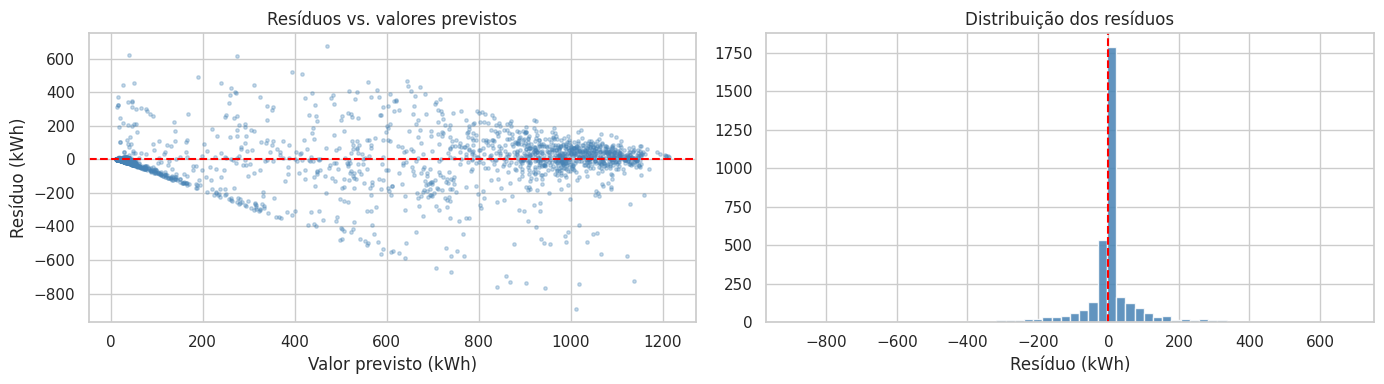

Bias médio (resíduo médio): -4.14 kWh
Desvio padrão dos resíduos: 112.40 kWh


In [ ]:
#  Avaliação final

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "RandomForest_Otimizado"
elif trained_models:
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None:
    y_pred_final = final_model.predict(X_test)

    # Adiciona resultado do modelo otimizado
    results[final_model_name] = evaluate_regression(y_test, y_pred_final)
    results[final_model_name]["train_time_s"] = "—"

    display(pd.DataFrame([evaluate_regression(y_test, y_pred_final)], index=[final_model_name]))

    # Resíduos
    residuals = np.array(y_test) - y_pred_final

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].scatter(y_pred_final, residuals, alpha=0.3, s=6, color="steelblue")
    axes[0].axhline(0, color="red", ls="--")
    axes[0].set_title("Resíduos vs. valores previstos")
    axes[0].set_xlabel("Valor previsto (kWh)")
    axes[0].set_ylabel("Resíduo (kWh)")

    axes[1].hist(residuals, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
    axes[1].axvline(0, color="red", ls="--")
    axes[1].set_title("Distribuição dos resíduos")
    axes[1].set_xlabel("Resíduo (kWh)")

    plt.tight_layout()
    plt.show()

    print(f"Bias médio (resíduo médio): {residuals.mean():.2f} kWh")
    print(f"Desvio padrão dos resíduos: {residuals.std():.2f} kWh")


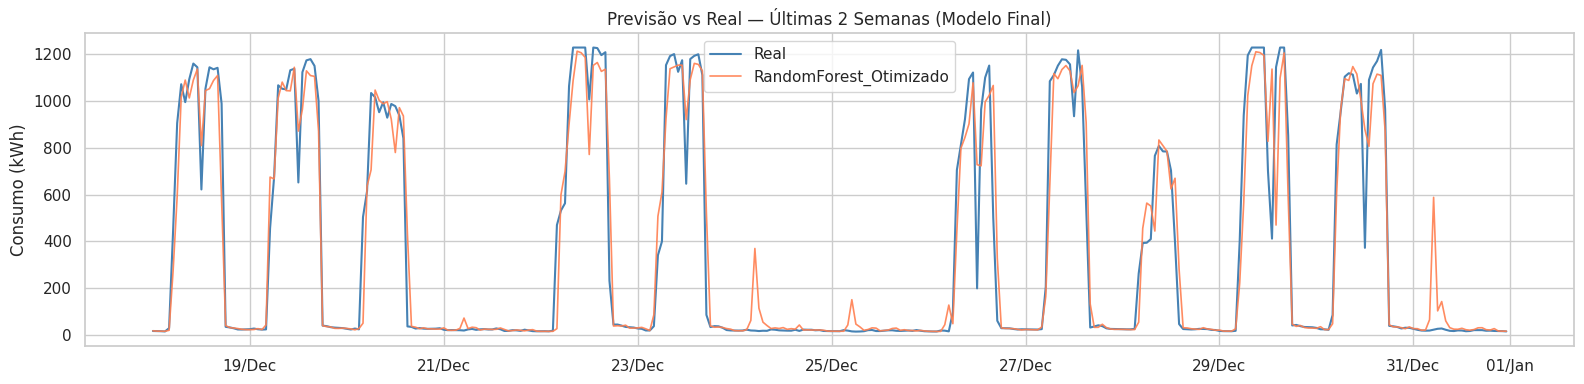

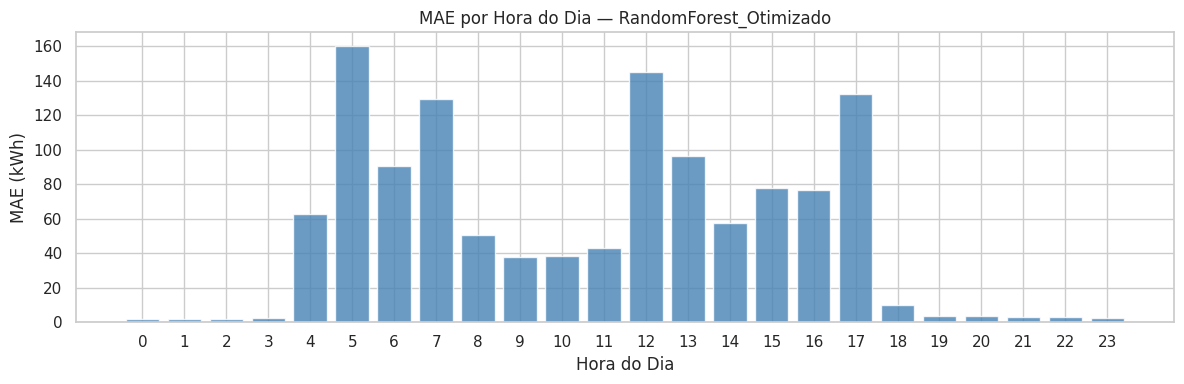

Hora com maior erro: 5h (160.0 kWh)
Hora com menor erro: 1h (1.6 kWh)


In [ ]:
# Previsão vs Real
plot_forecast(
    ts=ts_test.values,
    y_true=y_test.values,
    y_pred=y_pred_final,
    titulo="Previsão vs Real — Últimas 2 Semanas (Modelo Final)",
    label_pred=final_model_name
)

# Erro por hora do dia
df_erro = pd.DataFrame({
    "hora": test_feat["hora"].values,
    "erro_abs": np.abs(y_test.values - y_pred_final)
})
erro_hora = df_erro.groupby("hora")["erro_abs"].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(erro_hora.index, erro_hora.values, color="steelblue", alpha=0.8)
ax.set_title(f"MAE por Hora do Dia — {final_model_name}")
ax.set_xlabel("Hora do Dia")
ax.set_ylabel("MAE (kWh)")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

print(f"Hora com maior erro: {erro_hora.idxmax()}h ({erro_hora.max():.1f} kWh)")
print(f"Hora com menor erro: {erro_hora.idxmin()}h ({erro_hora.min():.1f} kWh)")


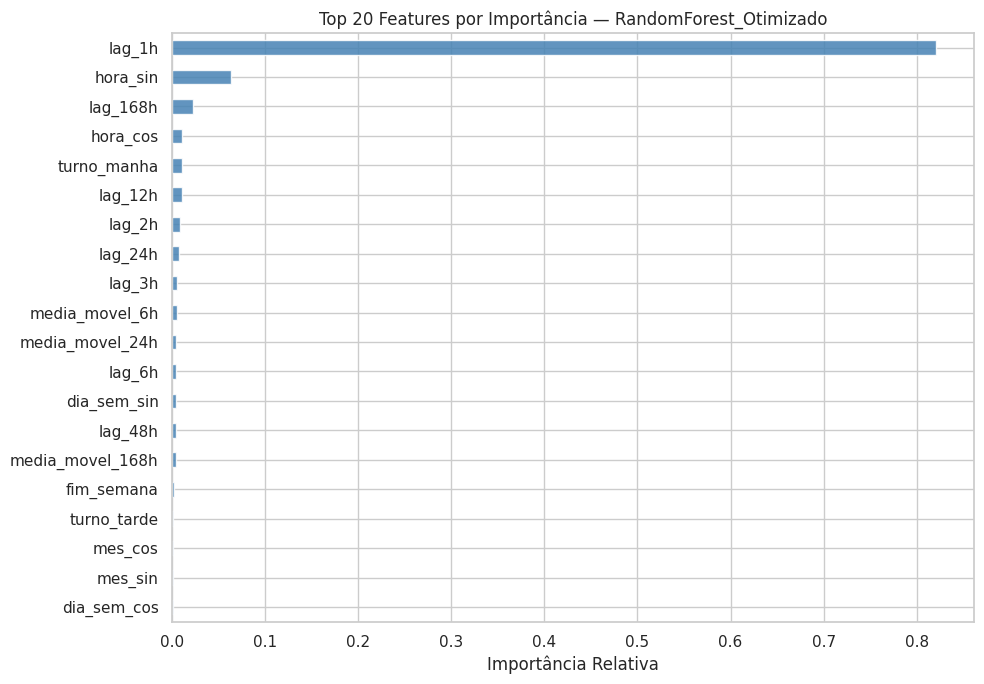

In [ ]:
#Importância das features
rf_step = final_model.named_steps["model"]
importancias = pd.Series(rf_step.feature_importances_, index=feature_cols)
importancias = importancias.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
importancias.plot(kind="barh", ax=ax, color="steelblue", alpha=0.85)
ax.set_title(f"Top 20 Features por Importância — {final_model_name}")
ax.set_xlabel("Importância Relativa")
plt.tight_layout()
plt.show()


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
**Quais erros o modelo comete mais?**
O erro não é uniforme ao longo do dia: concentra-se nas **horas de transição de turno**, com pico de erro médio às 5h (~160 kWh), justamente quando o consumo dispara da parada noturna para o regime de produção. Nas horas de regime estável o erro é baixíssimo (mínimo de ~1,7 kWh à 1h da manhã). O padrão é coerente com a EDA: o que é difícil de prever é a *rampa* abrupta de ligar/desligar a operação, não os patamares. Fins de semana e feriados, sem uma feature explícita de feriado, também tendem a gerar erros maiores por terem perfil atípico.

**Há overfitting ou underfitting?**
Não há sinais de underfitting: o R² de 0,93 e o RMSE de 112,47 kWh (contra 316,98 do baseline) mostram que o modelo captura bem a estrutura dos dados. Quanto a overfitting, a evidência decisiva é a concordância entre o erro de validação cruzada (RMSE 129,6 kWh, TimeSeriesSplit) e o erro no teste (112,47 kWh): o desempenho fora da amostra é estável e o teste não é pior que a CV — inclusive é um pouco melhor, o que é esperado porque os primeiros folds do TimeSeriesSplit treinam com menos histórico. O Random Forest naturalmente ajusta bem o treino (erro de treino baixo é característico do algoritmo), mas isso não se traduz em queda de desempenho fora da amostra, então não há overfitting que prejudique o uso prático.

**A métrica escolhida captura bem o objetivo?**
O RMSE (métrica principal) é adequado porque penaliza erros grandes, que são os mais custosos na operação. O MAPE, por outro lado, é enganoso aqui (54% no modelo final): ele é inflado pelas horas de consumo quase nulo, onde um erro absoluto pequeno vira um percentual enorme. Por isso o **WAPE (16,27%)** é a leitura percentual fiel — o erro total equivale a ~16% do consumo total do período. O resíduo médio de **−4,14 kWh** (frente a um consumo médio de ~350 kWh) indica que o modelo é praticamente não-enviesado, sem tendência sistemática a super ou subestimar.

**Há viés, limitação de dados ou risco de generalização?**
O viés sistemático é desprezível (resíduo médio ≈ 0). O desvio-padrão dos resíduos (112,40 kWh) é praticamente igual ao RMSE, o que indica que o erro se comporta como ruído distribuído em torno de zero, e não como uma tendência. As principais limitações são: (a) previsão de apenas **1 hora à frente**, pois o modelo depende do consumo real da hora anterior (lags realizados); (b) ausência de variáveis exógenas (temperatura, volume de produção, feriados, paradas de manutenção); (c) a premissa de que o processo produtivo não muda estruturalmente — instalação de novos equipamentos ou mudança de regime de produção exigiria retreino.

**Em quais cenários o modelo não deveria ser usado?**
- Para **planejamento de várias horas à frente** sem adaptar a abordagem (multi-step direto ou recursivo): como ele usa o consumo real da hora anterior, prever 6h/12h adiante exigiria realimentar previsões, com erro acumulado crescente.
- **Após mudanças estruturais** na operação (novos equipamentos, nova linha) sem retreino, pois os padrões aprendidos deixam de valer.
- Em **feriados ou paradas atípicas** não representados no histórico de treino.
- Como **detector de anomalias** puro: o modelo prevê o consumo esperado, mas usá-lo para alertas exigiria definir limiares sobre os resíduos, o que é um passo adicional não calibrado neste MVP.

# 11. Comparação final dos modelos

Síntese comparativa de todos os modelos no conjunto de teste, ordenados do melhor para o pior RMSE (métrica principal).

| Modelo | RMSE (kWh) ↓ | MAE (kWh) | R² | WAPE | MAPE | Tempo de treino | Observações |
|---|---:|---:|---:|---:|---:|---:|---|
| **Random Forest Otimizado** | **112,47** | 51,22 | 0,931 | 16,3% | 54,3% | ≈1 min (estimado, busca completa: 50 fits) | **Melhor modelo.** `max_depth=17, n_estimators=183, min_samples_split=5, min_samples_leaf=4`. Ganho de ~1% sobre o RF padrão. |
| Random Forest (padrão) | 113,80 | 52,51 | 0,929 | 16,7% | 59,5% | 32,870 s | Já quase tão bom quanto o otimizado; defaults eram adequados. |
| Gradient Boosting | 119,82 | 62,38 | 0,921 | 19,8% | 89,5% | 10,794 s | Ligeiramente abaixo do RF neste problema. |
| Ridge | 168,10 | 104,22 | 0,845 | 33,1% | 216,3% | 0,03 s | Linear: captura parte do padrão, mas sofre underfitting. |
| Baseline (média por hora) | 316,78 | 235,36 | 0,451 | 74,8% | 693,0% | 0,001 s | Referência ingênua. |
| SARIMA(1,0,1)(1,0,1)[24] | 370,26 | 243,78 | 0,249 | 77,5% | 342,2% | 31,156 s | **Pior que o baseline** — forecast multi-step de horizonte longo, sem lags realizados; comparação desfavorável por construção. |

> **Comentário:** o RMSE do baseline (316,78 kWh) é a referência. O Random Forest Otimizado reduz esse erro em ~65%, com WAPE de apenas 16,3% — o erro total equivale a ~16% do consumo total do período. A coluna MAPE é incluída por transparência, mas é inflada pelas horas de consumo quase nulo (madrugada/parada), por isso o WAPE é a leitura percentual mais confiável.



# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Item | Valor / Decisão |
|---|---|
| **Seed global** | 160200 (fixada em numpy, random) |
| **Winsorizing** | Percentis 0,5–99,5% (limites do treino), aplicado à série antes das features; 82 pontos ajustados (0,47%) |
| **Engenharia de features** | Lags, médias móveis e encodings cíclicos criados sobre série ordenada |
| **Divisão temporal** | Holdout 80/20 cronológico — sem embaralhamento |
| **Validação cruzada** | TimeSeriesSplit(n_splits=5) na otimização de hiperparâmetros |
| **Modelos testados** | Baseline (média), Ridge, Random Forest, Gradient Boosting, SARIMA |
| **Modelo final** | Random Forest Otimizado (RandomizedSearchCV, n_iter=10) |
| **Tempo de treino** | Ridge: ~1s, RF: ~33s, GBM: ~11s, SARIMA: ~35s, Busca de Hiperparâmetros ~1min |
| **Recursos computacionais** | Google Colab — CPU, sem GPU (não necessária para este problema) |
| **Limitações conhecidas** | não leva em consideração possíveis consertos em máquinas e entre outros fatos do dia a dia normais em operações industriais |


## 13. Conclusão

**Objetivo do trabalho:** construir e avaliar modelos de Machine Learning para prever o consumo horário de energia elétrica (kWh) de uma fábrica de água mineral, apoiando decisões operacionais de otimização energética.

**Melhor solução encontrada:** o **Random Forest Otimizado** (busca aleatória com TimeSeriesSplit) apresentou o melhor desempenho no conjunto de teste — RMSE 112,47 kWh, MAE 51,22 kWh, WAPE 16,3% e R² 0,931 — superando o baseline ingênuo (média histórica por hora) em RMSE, MAE, WAPE e R².

**Comparação com baseline e critério de sucesso:** o RMSE caiu de 316,78 kWh (baseline) para 112,47 kWh, uma **redução de ~65%** — muito acima do critério mínimo de 20% definido na Seção 1.4, que portanto foi **atendido com folga**. O ganho vem da sensibilidade ao contexto recente (lags) e aos padrões de turno/sazonalidade, que o baseline ignora. Sobre a métrica percentual: o MAPE é alto (54% no melhor modelo) por ser dominado pelas horas de consumo quase nulo (madrugada/parada); por isso o WAPE (16%) é a leitura percentual mais fiel do desempenho.

**Principais aprendizados:**
- A **engenharia de features** (lags + encodings cíclicos + médias móveis) foi o fator mais determinante para o desempenho — mais impactante que a escolha entre RF e GBM. A otimização de hiperparâmetros trouxe ganho marginal (~1% sobre o RF padrão), indicando que os valores padrão já estavam próximos do ótimo.
- A comparação **ML vs. SARIMA** precisa considerar o horizonte: o SARIMA, prevendo todo o período de uma vez e sem lags realizados, ficou abaixo até do baseline (RMSE 370,26 vs. 316,78), enquanto os modelos de ML, com lags reais, fazem previsão de 1 hora à frente. São paradigmas com horizontes de previsão diferentes.
- A **hora de transição de turno** (maior erro às 5h, ~160 kWh) é o período mais difícil de prever — foco natural de melhorias.

**Limitações:**
- Previsão de apenas **1 hora à frente** (usa o consumo real da hora anterior); para horizontes maiores seria necessária previsão recursiva ou direta, com erro acumulado maior.
- Ausência de variáveis exógenas (temperatura, volume de produção, calendário de feriados e de paradas de manutenção).

**Próximos passos:**
- Incorporar feriados, temperatura e volume de produção como features exógenas.
- Implementar previsão multi-step (6h, 12h, 24h à frente) com estratégia direta ou recursiva, medindo a degradação do erro por horizonte.
- Avaliar modelos sequenciais (LSTM, Temporal Fusion Transformer) com mais histórico.
- Integrar o modelo a um sistema de alerta de consumo anômalo em tempo real.

> O MVP demonstrou ser viável construir um modelo de previsão de consumo energético com dados reais industriais e ferramentas open-source, atingindo o critério de sucesso definido e com potencial de aplicação operacional.